<a href="https://colab.research.google.com/github/LGLV-Ciencia-de-Datos/Curso_python_Ciencia_de_Datos/blob/main/b)_Missing_Values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Valores faltantes
Los valores faltantes ocurren. Prepárate para este desafío común en conjuntos de datos reales.
En este tutorial, aprenderás tres enfoques para tratar con valores faltantes. Luego, compararás la eficacia de estos enfoques en un conjunto de datos del mundo real.


# Introducción
Existen muchas formas en las que los datos pueden acabar con valores faltantes. Por ejemplo:

* Una casa de 2 habitaciones no incluirá un valor para el tamaño de una tercera habitación.
* Un encuestado puede optar por no compartir su ingreso.

La mayoría de las librerías de aprendizaje automático (incluyendo scikit-learn) generan un error si intentas construir un modelo con datos que contienen valores faltantes. Por lo tanto, deberás escoger una de las estrategias que se presentan a continuación.

# **Tres enfoques**

###1. **Una opción sencilla**: eliminar columnas con valores faltantes.


La opción más simple es eliminar las columnas que contienen valores ausentes.

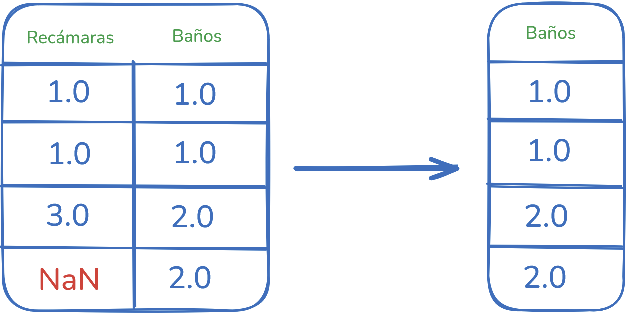

A menos que la mayoría de los valores en las columnas eliminadas sean faltantes, el modelo pierde acceso a mucha información (¡potencialmente útil!) con este enfoque. Como ejemplo extremo, considera un conjunto de datos con 10.000 filas, donde una columna importante carece de una sola entrada. ¡Este enfoque eliminaría la columna por completo!

### **2. Una opción mejor**: imputación

La imputación llena los valores faltantes con algún número. Por ejemplo, podemos rellenar con el valor promedio (mean) de cada columna.

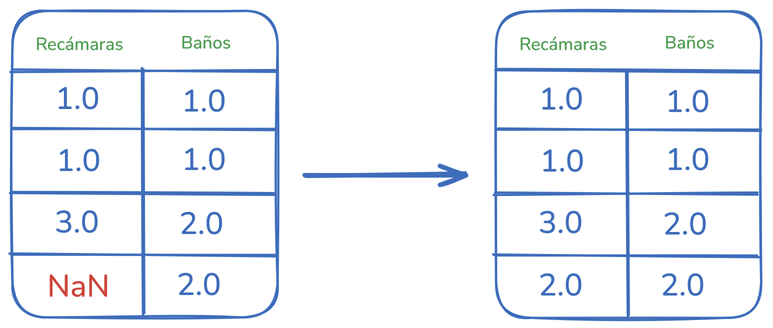

El valor imputado no será exactamente correcto en la mayoría de los casos, pero suele conducir a modelos más precisos que si se eliminara la columna por completo.

### 3. **Una extensión a la imputación**
La imputación es el método estándar y suele funcionar bien. Sin embargo, los valores imputados pueden estar sistemáticamente por encima o por debajo de sus valores reales (que no se recogieron en el conjunto de datos). O las filas con valores faltantes pueden ser únicas de alguna otra forma. En ese caso, tu modelo haría predicciones más precisas considerando qué valores estaban originalmente ausentes.

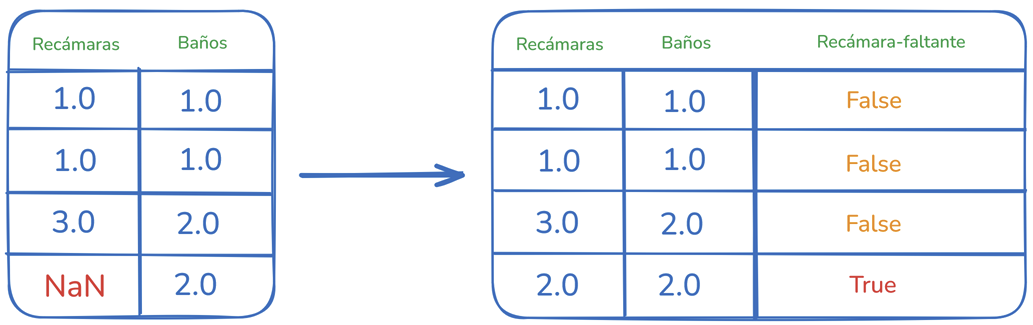

En este enfoque, imputamos los valores faltantes, como antes. Además, para cada columna con entradas ausentes en el conjunto de datos original, añadimos una nueva columna que indica la ubicación de las entradas imputadas. En algunos casos, esto mejorará los resultados de manera significativa. En otros, no aportará ninguna ayuda.

### **Ejemplo**
En el ejemplo, trabajaremos con el conjunto de datos de viviendas de Melbourne. Nuestro modelo utilizará información como el número de habitaciones y el tamaño del terreno para predecir el precio de la vivienda.
No nos centraremos en la fase de carga de datos. En su lugar, puedes imaginar que ya tienes los datos de entrenamiento y validación en X_train, X_valid, y_train y y_valid.

In [ ]:
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")

print("Path to dataset files:", path)

# Load the data into a pandas DataFrame
melbourne_file_path = path + '/melb_data.csv'
melbourne_data = pd.read_csv(melbourne_file_path)

# Print the first 5 rows of the DataFrame
display(melbourne_data.shape)

Using Colab cache for faster access to the 'melbourne-housing-snapshot' dataset.
Path to dataset files: /kaggle/input/melbourne-housing-snapshot


(13580, 21)

In [ ]:
from sklearn.model_selection import train_test_split

y = melbourne_data.Price

# To keep things simple, we'll use only numerical predictors
melb_predictors = melbourne_data.drop(['Price'], axis=1)
X = melb_predictors.select_dtypes(exclude=['object'])

# Divide data into training and validation subsets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                      random_state=0)

Definir una función para medir la calidad de cada enfoque.

Definimos una función llamada score_dataset() para comparar diferentes enfoques para tratar los valores faltantes. Esta función informa del error absoluto medio (MAE) obtenido con un modelo de bosque aleatorio.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def score_dataset(X_train, X_valid, y_train, y_valid):

    '''Esta funcion crea, entrena y calcula el desempeño del modelo'''

    model = RandomForestRegressor(n_estimators=10, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)

### **Puntuación del Enfoque 1** (Eliminar columnas con valores faltantes)
Dado que trabajamos con conjuntos de entrenamiento y validación, nos aseguramos de eliminar las mismas columnas en ambos marcos de datos.

In [ ]:
# Get names of columns with missing values
cols_with_missing = [col for col in X_train.columns
                     if X_train[col].isnull().any()]

# Drop columns in training and validation data
reduced_X_train = X_train.drop(cols_with_missing, axis=1) # axis=0 filas, axis=1 columnas
reduced_X_valid = X_valid.drop(cols_with_missing, axis=1) # axis=0 filas, axis=1 columnas

print("MAE from Approach 1 (Drop columns with missing values):")
print(score_dataset(reduced_X_train, reduced_X_valid, y_train, y_valid))

MAE from Approach 1 (Drop columns with missing values):
183550.22137772635


### **Puntuación del Enfoque 2** (Imputación)
A continuación, utilizamos `SimpleImputer` para reemplazar los valores faltantes con el media en cada columna.

Aunque es sencillo, rellenar con la media suele funcionar bastante bien (aunque esto varía según el conjunto de datos). Aunque los estadísticos han experimentado con métodos más complejos para determinar los valores imputados (como la imputación por regresión, por ejemplo), las estrategias complejas generalmente no aportan beneficios adicionales una vez que se introducen los resultados en modelos de aprendizaje automático sofisticados.

In [ ]:
# Importamos la clase SimpleImputer desde scikit-learn.
# Esta herramienta es para rellenar datos faltantes (NaN) en un DataFrame o array.
from sklearn.impute import SimpleImputer
# Importamos pandas, que se usa para manejar DataFrames.
import pandas as pd

# Creamos una instancia de la clase SimpleImputer.
# Por defecto, SimpleImputer usará la media (mean) de cada columna para rellenar los valores faltantes.
# Esto crea un objeto "my_imputer" que podemos usar para procesar nuestros datos.
my_imputer = SimpleImputer()

# Ajustamos (fit) el imputador y luego transformamos (transform) los datos de entrenamiento.
# `fit()`: El imputador aprende qué valores usar para la imputación (ej. calcula la media de cada columna)
#          basándose SÓLO en los datos de entrenamiento (`X_train`).
# `transform()`: Rellena los valores faltantes en `X_train` usando los valores que aprendió en el paso anterior.
# `pd.DataFrame(...)`: El resultado de `fit_transform` es un array de NumPy. Lo convertimos de nuevo a un DataFrame de Pandas.
imputed_X_train = pd.DataFrame(my_imputer.fit_transform(X_train))

# Transformamos los datos de validación.
# Solo usamos `transform()` y NO `fit_transform()`.
# Esto es crucial para evitar el "data leakage" (fuga de información).
# El imputador usa los mismos valores (medias, etc.) que aprendió de los datos de entrenamiento para rellenar los datos de validación.
# Esto asegura que el procesamiento sea consistente entre ambos conjuntos de datos.
# `pd.DataFrame(...)`: Convertimos el resultado a un DataFrame de Pandas.
imputed_X_valid = pd.DataFrame(my_imputer.transform(X_valid))


In [ ]:
print("MAE from Approach 2 (Imputation):")
print(score_dataset(imputed_X_train, imputed_X_valid, y_train, y_valid))

MAE from Approach 2 (Imputation):
178166.46269899711


Vemos que el `Enfoque 2` tiene un `MAE` menor que el `Enfoque 1`, por lo que el **`Enfoque 2`** obtuvo un mejor rendimiento en este conjunto de datos.

### **Puntuación del Enfoque 3** (Una extensión para la imputación)
A continuación, imputamos los valores faltantes, manteniendo también un registro de cuáles valores fueron imputados.

In [ ]:
# Make copy to avoid changing original data (when imputing)
X_train_plus = X_train.copy() # Crea una copia del conjunto de entrenamiento original para evitar modificar 'X_train' directamente.
X_valid_plus = X_valid.copy()   # Crea una copia del conjunto de validación original para evitar modificar 'X_valid' directamente.

# Make new columns indicating what will be imputed
for col in cols_with_missing: # Inicia un bucle que itera sobre cada columna en la lista 'cols_with_missing' (columnas que tienen NaNs).
    X_train_plus[col + '_was_missing'] = X_train_plus[col].isnull() # Crea una nueva columna booleana en 'X_train_plus' (ej. 'Age_was_missing').
                                                                   # Esta columna es 'True' si el valor original en 'col' era faltante (NaN), y 'False' en caso contrario.
    X_valid_plus[col + '_was_missing'] = X_valid_plus[col].isnull()   # Hace lo mismo para el conjunto de validación, creando una columna indicadora de valores faltantes.

# Imputation
my_imputer = SimpleImputer() # Inicializa la clase SimpleImputer de scikit-learn (por defecto, usa la media para rellenar los valores faltantes).
imputed_X_train_plus = pd.DataFrame(my_imputer.fit_transform(X_train_plus)) # Ajusta (calcula las medias/medianas) el imputador con los datos de entrenamiento ('X_train_plus').
                                                                            # Luego, transforma ('rellena' los NaNs) los datos de entrenamiento con los valores aprendidos.
                                                                            # El resultado (un array de NumPy) se convierte de nuevo a un DataFrame de Pandas.
imputed_X_valid_plus = pd.DataFrame(my_imputer.transform(X_valid_plus))   # Aplica la transformación al conjunto de validación ('X_valid_plus') utilizando los parámetros (medias/medianas)
                                                                          # que el imputador *aprendió* del conjunto de entrenamiento.
                                                                          # Esto evita la fuga de información (data leakage).

# Imputation removed column names; put them back
imputed_X_train_plus.columns = X_train_plus.columns # Asigna los nombres de columna originales (incluyendo las nuevas columnas '_was_missing')
                                                   # al DataFrame de entrenamiento imputado, ya que 'fit_transform' los elimina.
imputed_X_valid_plus.columns = X_valid_plus.columns   # Hace lo mismo para el DataFrame de validación imputado.

print("MAE from Approach 3 (An Extension to Imputation):") # Imprime un encabezado descriptivo en la consola.
print(score_dataset(imputed_X_train_plus, imputed_X_valid_plus, y_train, y_valid)) # Llama a la función 'score_dataset' (que debe estar definida en otro lugar)
                                                                                  # para evaluar la calidad del modelo entrenado en los datos imputados y validados.


MAE from Approach 3 (An Extension to Imputation):
178927.503183954


### Comparamos los tres enfoques.

In [ ]:
print("MAE from Approach 1 (Drop columns with missing values):")
print(score_dataset(reduced_X_train, reduced_X_valid, y_train, y_valid))
print("\nMAE from Approach 2 (Imputation):")
print(score_dataset(imputed_X_train, imputed_X_valid, y_train, y_valid))
print("\nMAE from Approach 3 (An Extension to Imputation):")
print(score_dataset(imputed_X_train_plus, imputed_X_valid_plus, y_train, y_valid))

MAE from Approach 1 (Drop columns with missing values):
183550.22137772635

MAE from Approach 2 (Imputation):
178166.46269899711

MAE from Approach 3 (An Extension to Imputation):
178927.503183954


Como podemos ver, el Enfoque 3 obtuvo un rendimiento ligeramente peor que el Enfoque 2.

Entonces, ¿por qué la imputación funcionó mejor que eliminar las columnas?

Los datos de entrenamiento tienen 10,864 filas y 12 columnas, donde tres columnas contienen datos faltantes. En cada columna, menos de la mitad de las registros son ausentes. Por lo tanto, eliminar las columnas elimina mucha información útil, y tiene sentido que la imputación funcione mejor.

In [ ]:
# Shape of training data (num_rows, num_columns)
#print(X_train.shape)

# Number of missing values in each column of training data
missing_val_count_by_column = (X_train.isnull().sum())
print(f'La cantidad de filas y columnas de los datos de entrenamiento son:\n{X_train.shape} \n')
print(f'Columnas con valores faltanes:\n{missing_val_count_by_column[missing_val_count_by_column > 0]}')

La cantidad de filas y columnas de los datos de entrenamiento son:
(10864, 12) 

Columnas con valores faltanes:
Car               49
BuildingArea    5156
YearBuilt       4307
dtype: int64


### **Conclusión**
Como es habitual, imputar los valores faltantes (en el Enfoque 2 y el Enfoque 3) arrojó mejores resultados en comparación con simplemente eliminar las columnas con valores ausentes (en el Enfoque 1).